**(Part 2)** Create a bar graph that shows the number of hours during which each patient's oxygen saturation (`O2Sat`) went below 95. Some patients do not have data from this particular sensor, so it is okay if they are excluded from your graph. Your plot should be clearly legible and properly labeled with axis labels and a title.

# Important: Run this code cell each time you start a new session!

In [16]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scipy
!pip install os
!pip install wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import os
import wfdb

ERROR: Could not find a version that satisfies the requirement os (from versions: none)
ERROR: No matching distribution found for os


In [ ]:
# Download some files of a sepsis dataset
sepsis_folder = "sepsis_dataset"
if not os.path.exists(sepsis_folder):
    os.mkdir(sepsis_folder)
patient_list = range(1, 11)
patient_list = [f'p{str(s).zfill(6)}.psv' for s in patient_list]
for f in patient_list:
  !wget -nc https://physionet.org/files/challenge-2019/1.0.0/training/training_setA/{f}
  os.rename(f, os.path.join(sepsis_folder, f))

In [ ]:
# Convert the sepsis dataset to a single csv
def load_single_file(file_path):
    df = pd.read_csv(file_path, sep="|")
    df['PatientID'] = file_path.split(os.sep)[-1][:-4]
    df['Hour'] = df.index
    keep_cols = ['PatientID', 'Age', 'Gender', 'SepsisLabel', 'Hour',
                 'HR', 'O2Sat', 'SBP', 'DBP', 'Resp']
    df = df[keep_cols]
    df.rename(columns={'Gender': 'Sex', 'SepsisLabel': 'HasSepsis'}, inplace=True)
    return df

def create_final_table(patient_list):
    final_df = pd.DataFrame()
    for f in patient_list:
        df = load_single_file(os.path.join(sepsis_folder, f))
        final_df = pd.concat([final_df, df])
    final_df.to_csv('sepsis.csv',index=False)
create_final_table(patient_list)

In [ ]:
# Load the PPG data
user = '100004'
signals, fields = wfdb.rdsamp(f'{user}_PPG', pn_dir=f'butppg/{user}')
ppg = signals.flatten()
ppg = ppg[:200]
ppg -= ppg.mean()
fs = fields['fs']
ppg_time = np.arange(len(ppg))/fs

# Save it in a DataFrame
df = pd.DataFrame()
df['Time'] = ppg_time
df['PPG'] = ppg
df.to_csv('ppg.csv', index=False)

In [ ]:
import os, datetime, json, locale, pathlib, urllib, requests, werkzeug, nbformat, google, yaml, warnings
def colab2pdf():
    locale.setlocale(locale.LC_ALL, 'en_US.UTF-8')
    NAME = pathlib.Path(werkzeug.utils.secure_filename(urllib.parse.unquote(requests.get(f"http://{os.environ['COLAB_JUPYTER_IP']}:{os.environ['KMP_TARGET_PORT']}/api/sessions").json()[0]["name"])))
    TEMP = pathlib.Path("/content/pdfs") / f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{NAME.stem}"; TEMP.mkdir(parents=True, exist_ok=True)
    NB = [cell for cell in nbformat.reads(json.dumps(google.colab._message.blocking_request("get_ipynb", timeout_sec=30)["ipynb"]), as_version=4).cells if "--Colab2PDF" not in cell.source]
    warnings.filterwarnings('ignore', category=nbformat.validator.MissingIDFieldWarning)
    with (TEMP / f"{NAME.stem}.ipynb").open("w", encoding="utf-8") as nb_copy: nbformat.write(nbformat.v4.new_notebook(cells=NB or [nbformat.v4.new_code_cell("#")]), nb_copy)
    if not pathlib.Path("/usr/local/bin/quarto").exists():
        !wget -q "https://quarto.org/download/latest/quarto-linux-amd64.deb" -P {TEMP} && dpkg -i {TEMP}/quarto-linux-amd64.deb > /dev/null && quarto install tinytex --update-path --quiet
    with (TEMP / "config.yml").open("w", encoding="utf-8") as file: yaml.dump({'include-in-header': [{"text": r"\usepackage{fvextra}\DefineVerbatimEnvironment{Highlighting}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines,breakanywhere,commandchars=\\\{\}}"}],'include-before-body': [{"text": r"\DefineVerbatimEnvironment{verbatim}{Verbatim}{breaksymbolleft={},showspaces=false,showtabs=false,breaklines}"}]}, file)
    !quarto render {TEMP}/{NAME.stem}.ipynb --metadata-file={TEMP}/config.yml --to pdf -M latex-auto-install -M margin-top=1in -M margin-bottom=1in -M margin-left=1in -M margin-right=1in --quiet
    google.colab.files.download(str(TEMP / f"{NAME.stem}.pdf"))

# Instructions

Please complete all of the exercises below. Across this module, some of the exercises are expected to produce very specific outputs, while others may have a variety of reasonable answers.

# Exercise 1: Visualizing Tabular Data

This exercise will involve the sepsis dataset we used in class.

In [ ]:
df = pd.read_csv("sepsis.csv")
df

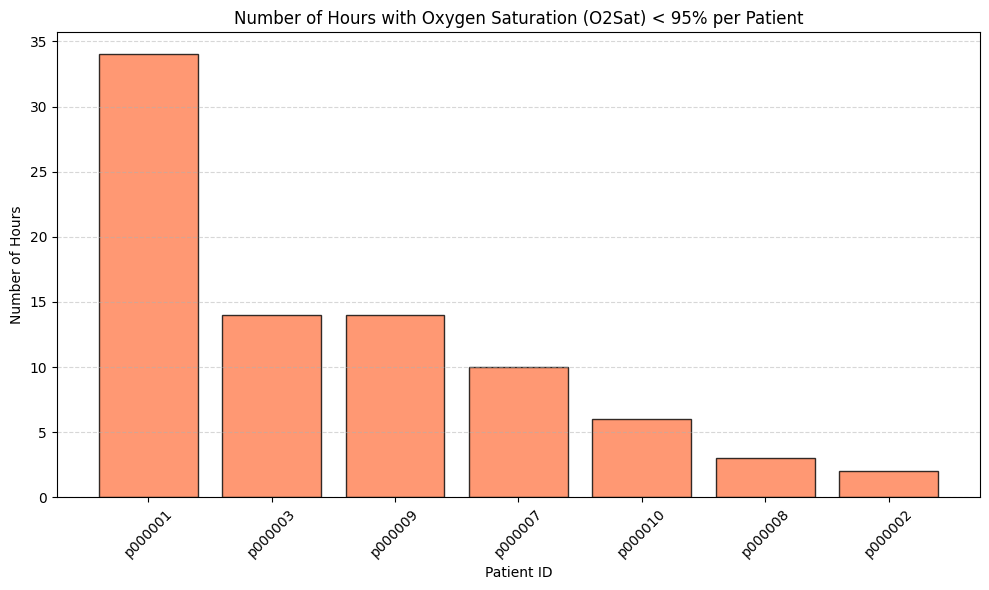

In [23]:
import matplotlib.pyplot as plt

# Filter the rows where O2Sat is strictly less than 95
low_o2_df = df[df['O2Sat'] < 95]

# Count the number of hours (rows) for each patient
patient_counts = low_o2_df.groupby('PatientID').size().sort_values(ascending=False)

# Plot the results as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(patient_counts.index, patient_counts.values, color='coral', edgecolor='black', alpha=0.8)

plt.title("Number of Hours with Oxygen Saturation (O2Sat) < 95% per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Number of Hours")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**(Part 1)** Create a line graph that shows the oxygen saturation data (`O2Sat`) for patients `p000008`, `p000009`, and `p000010` over time. Your plot should be clearly legible and properly labeled with axis labels, a title, and a legend.

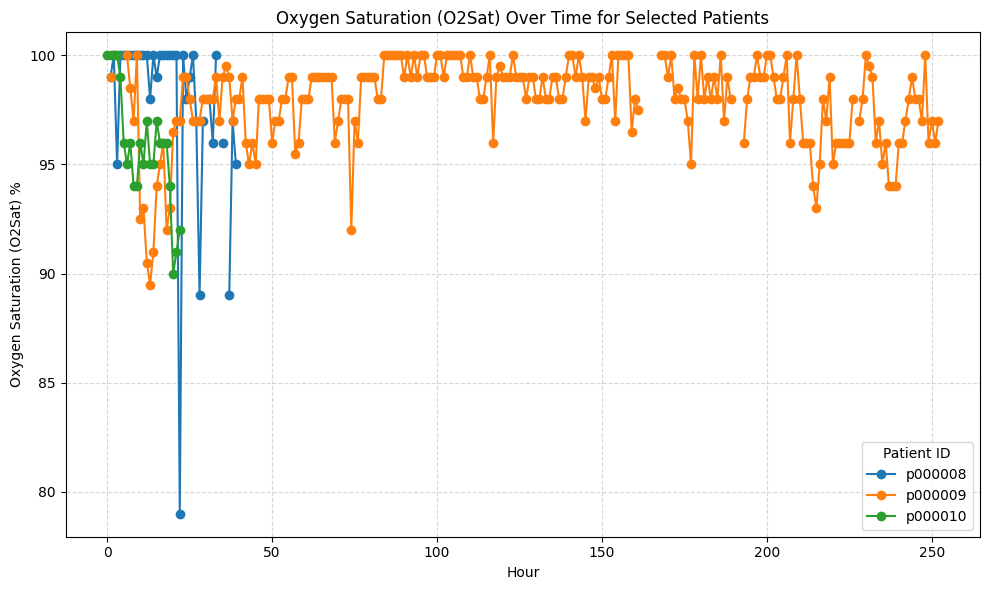

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the sepsis dataset
sepsis_df = pd.read_csv('sepsis.csv')

# Filter for the requested patients
target_patients = ['p000008', 'p000009', 'p000010']
filtered_sepsis = sepsis_df[sepsis_df['PatientID'].isin(target_patients)]

# Create the line graph
plt.figure(figsize=(10, 6))
for patient in target_patients:
    patient_data = filtered_sepsis[filtered_sepsis['PatientID'] == patient].sort_values('Hour')
    plt.plot(patient_data['Hour'], patient_data['O2Sat'], marker='o', label=patient)

plt.title('Oxygen Saturation (O2Sat) Over Time for Selected Patients')
plt.xlabel('Hour')
plt.ylabel('Oxygen Saturation (O2Sat) %')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Patient ID')
plt.tight_layout()
plt.show()

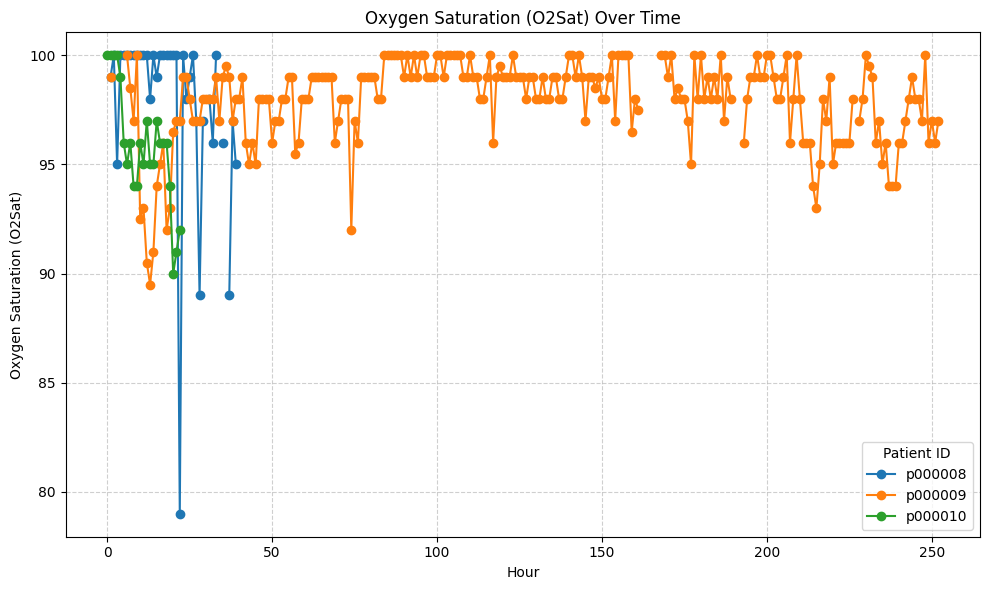

In [19]:
import matplotlib.pyplot as plt

# Filter the dataframe for the specified patients
target_patients = ['p000008', 'p000009', 'p000010']
filtered_df = df[df['PatientID'].isin(target_patients)]

# Plot the O2Sat data over time for each patient
plt.figure(figsize=(10, 6))
for patient in target_patients:
    patient_df = filtered_df[filtered_df['PatientID'] == patient]
    # Sorting by Hour ensures the line is drawn chronologically
    patient_df = patient_df.sort_values(by='Hour')
    plt.plot(patient_df['Hour'], patient_df['O2Sat'], marker='o', label=patient)

plt.title('Oxygen Saturation (O2Sat) Over Time')
plt.xlabel('Hour')
plt.ylabel('Oxygen Saturation (O2Sat)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Patient ID')
plt.tight_layout()
plt.show()

**(Part 2)** Create a bar graph that shows the number of hours during which each patient's oxygen saturation (`O2Sat`) went below 95. Some patients do not have data from this particular sensor, so it is okay if they are excluded from your graph. Your plot should be clearly legible and properly labeled with axis labels and a title.

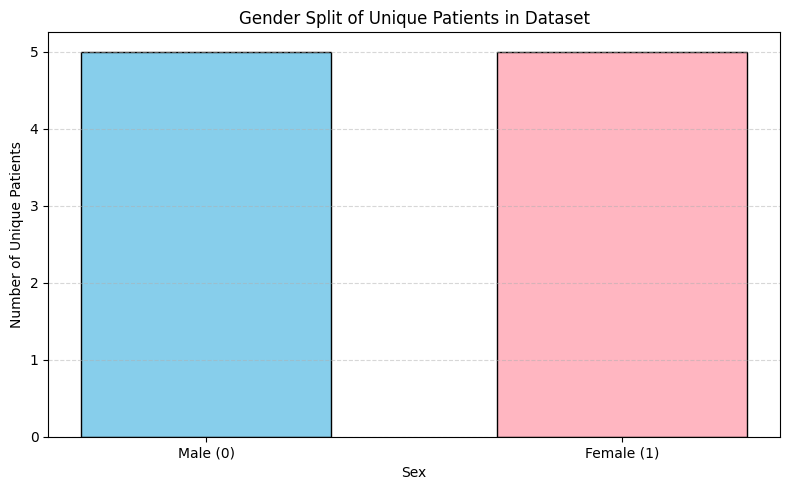

In [26]:
import matplotlib.pyplot as plt

# Get unique patients and their associated sex
unique_patients = df.drop_duplicates(subset=['PatientID'])

# Count the number of male (0) and female (1) patients
sex_counts = unique_patients['Sex'].value_counts()

# Map the indices to descriptive labels for clarity
labels = ['Male (0)' if idx == 0 else 'Female (1)' for idx in sex_counts.index]

# Plot the results as a bar graph
plt.figure(figsize=(8, 5))
plt.bar(labels, sex_counts.values, color=['skyblue', 'lightpink'], edgecolor='black', width=0.6)

plt.title("Gender Split of Unique Patients in Dataset")
plt.xlabel("Sex")
plt.ylabel("Number of Unique Patients")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [25]:
# Write your code here

**(Part 3)** Create a bar graph that shows the split between male (`0`) and female (`1`) patients in the dataset. Remember that there are multiple entries per patient in this table. Your graph should not reflect the number of rows in the `DataFrame`, but rather the number of unique patients in the dataset. Your plot should be clearly legible and properly labeled with axis labels and a title.

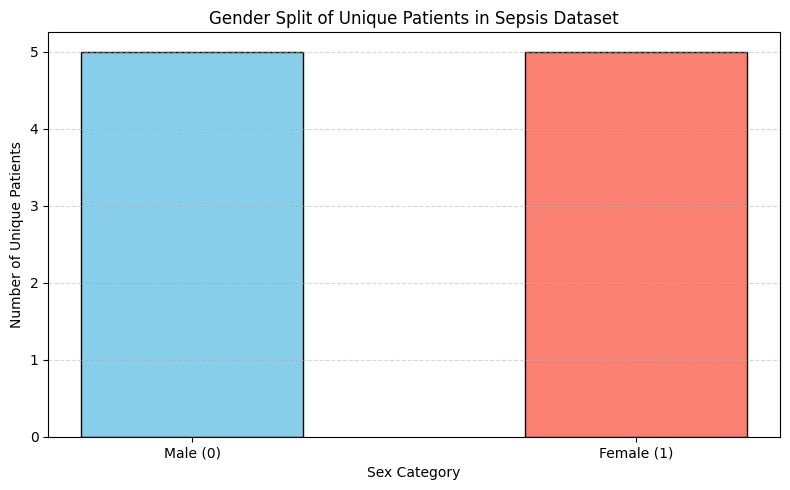

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the sepsis dataset
sepsis_df = pd.read_csv('sepsis.csv')

# Drop duplicates to keep only one record per unique patient
unique_patients = sepsis_df.drop_duplicates(subset=['PatientID'])

# Count the number of male (0) and female (1) patients
sex_counts = unique_patients['Sex'].value_counts()

# Map numerical categories to descriptive labels for the plot axes
labels = ['Male (0)' if idx == 0 else 'Female (1)' for idx in sex_counts.index]

# Create the bar graph
plt.figure(figsize=(8, 5))
plt.bar(labels, sex_counts.values, color=['skyblue', 'salmon'], edgecolor='black', width=0.5)

plt.title('Gender Split of Unique Patients in Sepsis Dataset')
plt.xlabel('Sex Category')
plt.ylabel('Number of Unique Patients')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Exercise 2: Working with PPG Data

This exercise will involve real-world data that was collected from a photoplethysmography (PPG) sensor. In short, this type of sensor relies on optically measuring the amount of blood that flows in and out of a peripheral site like a fingertip to capture the cardiac waveform.

In [ ]:
df = pd.read_csv("ppg.csv")
df

**(Part 1)** Create a line graph that shows the PPG data over time. Your plot should be clearly legible and properly labeled with axis labels and a title.

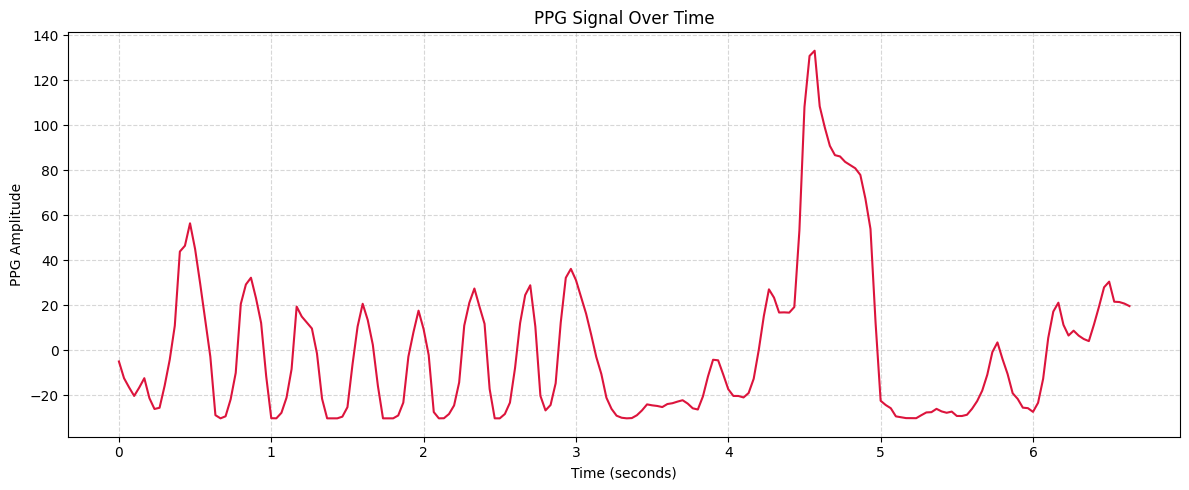

In [27]:
import matplotlib.pyplot as plt

# Load the PPG data
ppg_df = pd.read_csv('ppg.csv')

# Plot the PPG waveform over time
plt.figure(figsize=(12, 5))
plt.plot(ppg_df['Time'], ppg_df['PPG'], color='crimson', linewidth=1.5)

plt.title("PPG Signal Over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("PPG Amplitude")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Notice that the first half of the signal looks like a consistent heartbeat, while the second half of the signal looks less consistent. This is likely because the patient moved their fingertip or the sensor during this recording.

**(Part 2)** Write code that will calculate the sampling rate of this signal.

In [29]:
# Calculate the sampling rate
# The sampling rate is defined as the number of samples per second.
# We can find the difference between consecutive time stamps to calculate the sampling interval (dt)
dt = ppg_df['Time'].diff().mean()
sampling_rate = 1.0 / dt

print(f"Sampling Interval (dt): {dt:.4f} seconds")
print(f"Calculated Sampling Rate: {sampling_rate:.2f} Hz")

Sampling Interval (dt): 0.0333 seconds
Calculated Sampling Rate: 30.00 Hz


**(Part 3)** Write code that uses a 0.5-second sliding window with 0% overlap to automatically identify when the PPG signal quality is high. You can use whatever metric(s) and thresholds you deem fit to define signal quality. This code should print out the start and end time of each window when the signal quality is high.

In [31]:
import numpy as np

# Parameters
window_duration = 0.5 # seconds
window_size = int(window_duration * sampling_rate) # 15 samples
overlap = 0
step_size = window_size

print(f"Window Size: {window_size} samples\n")
print("High Quality Windows:")
print("---------------------")

high_quality_windows = []

for i in range(0, len(ppg_df) - window_size + 1, step_size):
    window_df = ppg_df.iloc[i:i+window_size]
    window_ppg = window_df['PPG']

    start_time = window_df['Time'].iloc[0]
    end_time = window_df['Time'].iloc[-1]

    # Signal quality metric: Standard deviation
    # High quality PPG waveforms usually have regular oscillations with std between 10 and 40
    # Extreme values or flatlines indicate noise or disconnection
    std_val = window_ppg.std()

    if 10 < std_val < 40:
        high_quality_windows.append((i, i + window_size, start_time, end_time))
        print(f"Start: {start_time:.2f}s | End: {end_time:.2f}s | Std Dev: {std_val:.2f}")

Window Size: 15 samples

High Quality Windows:
---------------------
Start: 0.00s | End: 0.47s | Std Dev: 27.68
Start: 0.50s | End: 0.97s | Std Dev: 25.48
Start: 1.00s | End: 1.47s | Std Dev: 19.39
Start: 1.50s | End: 1.97s | Std Dev: 19.28
Start: 2.00s | End: 2.47s | Std Dev: 21.73
Start: 2.50s | End: 2.97s | Std Dev: 24.55
Start: 3.00s | End: 3.47s | Std Dev: 21.70
Start: 4.00s | End: 4.47s | Std Dev: 22.76
Start: 4.50s | End: 4.97s | Std Dev: 29.71
Start: 5.50s | End: 5.97s | Std Dev: 10.84
Start: 6.00s | End: 6.47s | Std Dev: 15.62


**(Part 4)** Pick the largest contiguous chunk of the PPG signal where the signal quality is high. Then, write code that will use a sliding window of your choosing to count the number of heartbeats in that part of the data.

Number of detected heartbeats: 4
Duration of high quality segment: 3.47 seconds
Estimated Heart Rate: 69.23 BPM



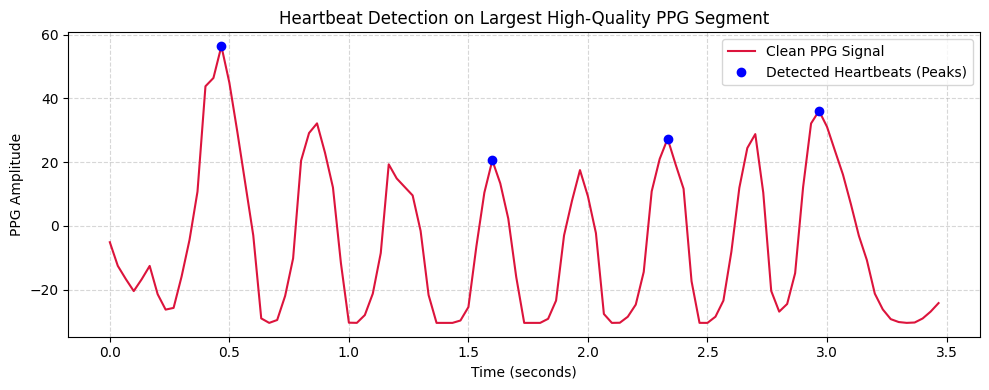

In [33]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

# The largest contiguous chunk of high quality PPG data is from 0.0s to 3.5s
# This corresponds to indices 0 to 105 in ppg_df (7 windows of 15 samples each)
good_ppg = ppg_df.iloc[0:105].copy()

# Find the peaks in the clean PPG signal
# Distance ensures we don't pick up double peaks within the same heartbeat cycle
peaks, _ = find_peaks(good_ppg['PPG'], distance=15, prominence=15)

num_heartbeats = len(peaks)
segment_duration = good_ppg['Time'].iloc[-1] - good_ppg['Time'].iloc[0]
heart_rate_bpm = (num_heartbeats / segment_duration) * 60

print(f"Number of detected heartbeats: {num_heartbeats}")
print(f"Duration of high quality segment: {segment_duration:.2f} seconds")
print(f"Estimated Heart Rate: {heart_rate_bpm:.2f} BPM\n")

# Let's plot the selected chunk and highlight the detected heartbeat peaks
plt.figure(figsize=(10, 4))
plt.plot(good_ppg['Time'], good_ppg['PPG'], label='Clean PPG Signal', color='crimson')
plt.plot(good_ppg['Time'].iloc[peaks], good_ppg['PPG'].iloc[peaks], "o", label='Detected Heartbeats (Peaks)', color='blue')
plt.title("Heartbeat Detection on Largest High-Quality PPG Segment")
plt.xlabel("Time (seconds)")
plt.ylabel("PPG Amplitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Prepare Submission

To get full credit for this assignment, you should submit your assignment in two formats so that we can easily grade and debug your code:
1. **.ipynb:** First, confirm that your code can run from start to finish without any errors. To check this, go to "Runtime" > "Run all" in the Google Colab menu. If everything looks good, you can export your file by going to "File" > "Download" > "Download .ipynb".
2. **.pdf:** Run the function called `colab2pdf()` below. This will automatically convert your notebook to a PDF. Note that while "File" > "Print" > "Save as PDF" also works, it requires you to manually expand all of the cells and may cut off some images.

In [38]:
colab2pdf()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>